# predicting the next move from the order book

next-day direction turned out to be close to a coin flip, because most of a daily move is overnight news that the price history cannot see. so i changed both the horizon and the data: instead of guessing tomorrow's close, i read the limit order book and predict whether the mid-price ticks up, flat, or down about 1 second ahead. the model is a CNN + LSTM that reads the book and the order flow, and it is judged on how often it calls direction right, especially on the moments it is most confident.

### about this notebook

Setup
- Data:
  - Databento MBP-10 order-book depth from Nasdaq: the top 10 levels, so 40 numbers per snapshot, sampled to one snapshot every 50ms.
  - tickers: QQQ, NVDA, MU, SPY, and TSLA.
  - SPY caveat: SPY is the one ticker read off a feed that is not its home venue (its primary listing is NYSE Arca, not Nasdaq). on the Nasdaq feed its book is still deep, so i keep it but flag any SPY result with this note.
  - the licensed depth data stays local (gitignored) and never goes into git.
- Split: by whole calendar day, shared across all tickers.
  - train: May 26 to Jun 3, 2026.
  - validation: Jun 4 to 5.
  - test: Jun 8 to 10, locked.
  - leak control: the label threshold and the scaler are fit on the training days only, per ticker, so nothing from val or test leaks in.
- Target:
  - 3-class direction (down / flat / up) of the smoothed mid-price about 1 second ahead.
  - the model also outputs a confidence, which is how i decide when to act.
- Model:
  - main model: a CNN + Inception + LSTM that reads the book, ending in a 3-class softmax, trained with a single fixed seed (42).
  - backbone: this is the DeepLOB architecture (Zhang, Zohren, Roberts 2019).
  - add-on: later i add a parallel order-flow branch as a second model, used only to push the up-vs-down call at high confidence.
- Held out:
  - TSLA is never trained on, kept only as a zero-shot transfer test.
- Baseline:
  - a plain logistic regression on the last snapshot, kept as the number to beat.

### how the model is judged

- primary metric:
  - QQQ macro-F1 on the locked Jun 8-10 test.
  - NVDA, MU, and SPY are reported per ticker, not folded into the headline.
- ceiling:
  - short-horizon moves are tick-size-bound, so a pooled score above 0.60 across the tickers would be a red flag for a leak.
- selective accuracy:
  - the model can abstain, so directional accuracy is always shown with coverage (what fraction of moments it acts on).
  - the acting threshold is fixed on validation, then applied once to the locked test.
  - directional accuracy is a strict up-vs-down call, so a flat outcome counts as a miss.
- leak protection:
  - whole day splits shared across tickers, so no window crosses a split.
  - the per ticker scaler and label threshold are fit on train days only.
  - the test is used only for final reporting, and every threshold is fixed on validation, never on test.
- caveat:
  - the headline ~73% at 50% coverage was measured on the same Jun 8-10 test i had already looked at while building the baseline.
  - fresh dates are needed to remove that asterisk.

In [1]:
# my order-book model, all names prefixed lob_ so it is self-contained, rebuilt leak-free
import warnings; warnings.filterwarnings("ignore")
import os, glob
import numpy as np, pandas as pd
np.seterr(all="ignore")
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv; load_dotenv()   # my databento key, read from .env which is gitignored

LOB_LEVELS, LOB_N_FEATURES = 10, 40
LOB_WINDOW, LOB_K, LOB_STRIDE = 100, 20, 35      # 5s of history, looking ~1s ahead at 50ms, one window every 35 rows
LOB_BIN  = "50ms"                                 # one book snapshot every 50ms
LOB_TICK = 0.01                                   # tick size in dollars, i scale prices into ticks
LOB_SYMBOLS  = ["QQQ", "NVDA", "MU", "SPY", "TSLA"]
LOB_HELD_OUT = "TSLA"                             # held out completely, i never train on it
LOB_PRIMARY  = "QQQ"                             # my main metric, picked before looking at anything

# i split by whole days, same days for every ticker so the rows line up
LOB_TRAIN_DATES = ["2026-05-26","2026-05-27","2026-05-28","2026-05-29","2026-06-01","2026-06-02","2026-06-03"]
LOB_VAL_DATES   = ["2026-06-04","2026-06-05"]
LOB_TEST_DATES  = ["2026-06-08","2026-06-09","2026-06-10"]   # locked, i only look at it once

LOB_DATASET, LOB_SCHEMA, LOB_STYPE_IN = "XNAS.ITCH", "mbp-10", "raw_symbol"
LOB_RAW_DIR = "data/raw"
LOB_COLS = []
for _lvl in range(1, LOB_LEVELS + 1):
    LOB_COLS += [f"ask_px_{_lvl}", f"ask_sz_{_lvl}", f"bid_px_{_lvl}", f"bid_sz_{_lvl}"]
tf.keras.utils.set_random_seed(42)

#### 1. getting the data

raw MBP-10 is metered by Databento, and a single QQQ session is about 2.8M events. the download below prices each pull for free first, skips files already on disk, and stops at a spend cap. the full 4-ticker by 12-day pull cost about $19 of the $125 credit, and the licensed depth data stays local (gitignored) and never goes into git.

In [2]:
# pulls the raw data to disk, skips files i already have, and stops if it would spend too much
LOB_RUN_DOWNLOAD = True
LOB_DRY_RUN      = False          # True just prices it, False actually pulls
LOB_MAX_SPEND    = 120.0          # spending ceiling to make sure i dont burn through all (free) credits
LOB_DATES        = ["2026-05-26", "2026-05-27", "2026-05-28", "2026-05-29", "2026-06-01", "2026-06-02", "2026-06-03", "2026-06-04", "2026-06-05", "2026-06-08", "2026-06-09", "2026-06-10"]

def _lob_et_to_utc(date_str, start_t, end_t):
    from datetime import datetime
    from zoneinfo import ZoneInfo
    ET, UTC = ZoneInfo("America/New_York"), ZoneInfo("UTC")
    d = datetime.fromisoformat(date_str).date()
    s = datetime.combine(d, start_t, tzinfo=ET).astimezone(UTC)
    e = datetime.combine(d, end_t,   tzinfo=ET).astimezone(UTC)
    return s.isoformat(), e.isoformat()

if LOB_RUN_DOWNLOAD:
    import os
    from datetime import time
    import databento as db
    client = db.Historical(key=os.environ["DATABENTO_S_KEY"])
    spent, stop = 0.0, False
    for sym in LOB_SYMBOLS:
        if stop: break
        for d in LOB_DATES:
            if stop: break
            for tag, t0, t1 in [("am", time(9, 30), time(11, 0)), ("pm", time(14, 30), time(16, 0))]:
                path = os.path.join(LOB_RAW_DIR, LOB_SCHEMA, sym, f"{d}_{tag}.dbn.zst")
                if os.path.exists(path) and os.path.getsize(path) > 0:
                    print("skip", sym, d, tag); continue
                s, e = _lob_et_to_utc(d, t0, t1)
                kw = dict(dataset=LOB_DATASET, symbols=[sym], schema=LOB_SCHEMA,
                          stype_in=LOB_STYPE_IN, start=s, end=e)
                est = client.metadata.get_cost(**kw)
                if spent + est > LOB_MAX_SPEND:
                    print(f"STOP: next pull (${est:.2f}) would exceed MAX_SPEND ${LOB_MAX_SPEND}"); stop = True; break
                spent += est
                print(("plan" if LOB_DRY_RUN else "pull"), sym, d, tag, f"${est:.2f}")
                if not LOB_DRY_RUN:
                    os.makedirs(os.path.dirname(path), exist_ok=True)
                    tmp = path + ".part"
                    if os.path.exists(tmp): os.remove(tmp)       # clear any half-finished file so a retry does not crash
                    client.timeseries.get_range(path=tmp, **kw)
                    os.replace(tmp, path)
    print(f"estimated run cost: ${spent:,.2f}")

skip QQQ 2026-05-26 am
skip QQQ 2026-05-26 pm
skip QQQ 2026-05-27 am
skip QQQ 2026-05-27 pm
skip QQQ 2026-05-28 am
skip QQQ 2026-05-28 pm
skip QQQ 2026-05-29 am
skip QQQ 2026-05-29 pm
skip QQQ 2026-06-01 am
skip QQQ 2026-06-01 pm
skip QQQ 2026-06-02 am
skip QQQ 2026-06-02 pm
skip QQQ 2026-06-03 am
skip QQQ 2026-06-03 pm
skip QQQ 2026-06-04 am
skip QQQ 2026-06-04 pm
skip QQQ 2026-06-05 am
skip QQQ 2026-06-05 pm
skip QQQ 2026-06-08 am
skip QQQ 2026-06-08 pm
skip QQQ 2026-06-09 am
skip QQQ 2026-06-09 pm
skip QQQ 2026-06-10 am
skip QQQ 2026-06-10 pm
skip NVDA 2026-05-26 am
skip NVDA 2026-05-26 pm
skip NVDA 2026-05-27 am
skip NVDA 2026-05-27 pm
skip NVDA 2026-05-28 am
skip NVDA 2026-05-28 pm
skip NVDA 2026-05-29 am
skip NVDA 2026-05-29 pm
skip NVDA 2026-06-01 am
skip NVDA 2026-06-01 pm
skip NVDA 2026-06-02 am
skip NVDA 2026-06-02 pm
skip NVDA 2026-06-03 am
skip NVDA 2026-06-03 pm
skip NVDA 2026-06-04 am
skip NVDA 2026-06-04 pm
skip NVDA 2026-06-05 am
skip NVDA 2026-06-05 pm
skip NVDA 2026-0

  - **split:** tag every session as train / validation / test by its date, whole days, so no window ever crosses a split.
  - **keep:** the price and size on both sides at all 10 book levels (which is a SPECIFIC price plus the total shares people want to trade at) (40 columns):
    - level 1: best ask price + size, best bid price + size,
    - levels 2 to 10: the same four numbers at each deeper price (the depth stacked behind the best price, so like the next, next next, ... next x10th best).
  - **drop:** every per-event column (action, side, flags, order counts).
  - **regrid:** resample the irregular events onto an even grid, one row every 50ms, keeping the last state in each 50ms bin cause those were good representation of the supply and demand, and the data also shows where the current price is

In [3]:
# turns the raw book into 40 features, one row every 50ms, one session at a time (for the CNN and LSTM)
def lob_split_of(date):
    if date in LOB_TRAIN_DATES: return 0
    if date in LOB_VAL_DATES:   return 1
    if date in LOB_TEST_DATES:  return 2
    return -1

def lob_build_book_from_dbn(path):
    # 40 raw levels, i keep the last state in each 50ms bin
    import databento as db
    df = db.DBNStore.from_file(path).to_df()
    out = pd.DataFrame(index=df.index)
    for lvl in range(LOB_LEVELS):
        out[f"ask_px_{lvl+1}"] = df[f"ask_px_{lvl:02d}"]; out[f"ask_sz_{lvl+1}"] = df[f"ask_sz_{lvl:02d}"]
        out[f"bid_px_{lvl+1}"] = df[f"bid_px_{lvl:02d}"]; out[f"bid_sz_{lvl+1}"] = df[f"bid_sz_{lvl:02d}"]
    out = out.replace([np.inf, -np.inf], np.nan).dropna().resample(LOB_BIN).last().ffill().dropna()
    return out[LOB_COLS].values.astype(np.float64)

def lob_load_blocks(symbol, include_test):
    # one (values, date, split) per file, and the test days only load when include_test is on
    blocks = []
    for f in sorted(glob.glob(f"{LOB_RAW_DIR}/{LOB_SCHEMA}/{symbol}/*.dbn.zst")):
        date = os.path.basename(f).split("_")[0]; sp = lob_split_of(date)
        if sp < 0 or (sp == 2 and not include_test):
            continue
        blocks.append((lob_build_book_from_dbn(f), date, sp))
    if not blocks:
        raise FileNotFoundError(f"no raw files for {symbol} in {LOB_RAW_DIR}/{LOB_SCHEMA}/{symbol}/ -- run the download cell first")
    return blocks

#### 2. labeling and stationary features

**label (smoothed 3-bin):** compare the average of the next k mids (mid prices) to the average of the previous k mids. it is up if that change is above `alpha`, down if below `-alpha`, else flat. `alpha` is set on the training days only, so the three classes stay balanced and nothing from val/test picks the threshold.

**features (stationary):** each price becomes `(price - mid) / tick` and each size becomes `log1p(size)`. raw prices drift and carry ticker identity, which is why a linear model on raw levels can outscore a CNN. both transforms use only the current snapshot, so they cannot leak.

tick - represents the smallest possible amount a stock could move, which is hard coded at the moment to 0.01

In [4]:
def lob_mid(v): return (v[:, 0] + v[:, 2]) / 2.0        # (ask_px_1 + bid_px_1) / 2

def lob_features(v):
    # stationary inputs: prices as an offset from the mid in ticks, sizes as log, using only this snapshot
    m = lob_mid(v); out = v.copy()
    for lvl in range(LOB_LEVELS):
        out[:, lvl*4+0] = (v[:, lvl*4+0] - m) / LOB_TICK   # ask price offset (ticks)
        out[:, lvl*4+2] = (v[:, lvl*4+2] - m) / LOB_TICK   # bid price offset (ticks)
        out[:, lvl*4+1] = np.log1p(v[:, lvl*4+1])          # ask size
        out[:, lvl*4+3] = np.log1p(v[:, lvl*4+3])          # bid size
    return out

def lob_smoothed_l(mid, k):
    n = len(mid); m_minus = np.full(n, np.nan); m_plus = np.full(n, np.nan)
    for t in range(n):
        if t - k + 1 >= 0: m_minus[t] = mid[t-k+1:t+1].mean()
        if t + k < n:      m_plus[t]  = mid[t+1:t+1+k].mean()
    return (m_plus - m_minus) / m_minus

def lob_choose_alpha(l_train): return np.nanquantile(np.abs(l_train), 1/3)   # ~1/3 end up flat, worked out on train only

def lob_label_from_l(l, alpha):
    y = np.full(len(l), 1, dtype=int)   # 1 = flat
    y[l > alpha]  = 2                    # 2 = up
    y[l < -alpha] = 0                    # 0 = down
    return y

#### 3. windows, normalization, and the leak-free split

- **windows:** the last `LOB_WINDOW=100` snapshots, shape `(100, 40)`, one window every `LOB_STRIDE=35` snapshots.
- **split:** by whole calendar day, shared across tickers (train May 26 to Jun 3, validate Jun 4-5, test Jun 8-10 locked). windows never span a session, so no window or its future label can cross a split, and no embargo is needed.
- **normalize:** a `StandardScaler` fit on the training-day snapshots only, kept per instrument, applied to val and test.
- **selection:** every choice (horizon, capacity, epoch) is made on validation macro-F1, and the locked test is touched once.

In [ ]:
def lob_make_windows_block(feats, labels, valid):
    X, y = [], []
    for j in range(LOB_WINDOW-1, len(feats), LOB_STRIDE):
        if not valid[j]:
            continue
        X.append(feats[j-LOB_WINDOW+1:j+1]); y.append(labels[j])
    return X, y

def lob_build_ticker(symbol, include_test=False, src_scaler=None, src_alpha=None):
    # alpha and scaler are fit on train days only, per ticker. the held-out ticker borrows the source ones
    blocks = lob_load_blocks(symbol, include_test)
    ls    = [lob_smoothed_l(lob_mid(v), LOB_K) for v, _, _ in blocks]
    feats = [lob_features(v) for v, _, _ in blocks]
    if src_alpha is None:
        train_l = np.concatenate([ls[i] for i in range(len(blocks)) if blocks[i][2] == 0])
        alpha = lob_choose_alpha(train_l)
    else:
        alpha = src_alpha
    if src_scaler is None:
        train_f = np.concatenate([feats[i] for i in range(len(blocks)) if blocks[i][2] == 0])
        scaler = StandardScaler().fit(train_f)
    else:
        scaler = src_scaler
    out = {0: ([], []), 1: ([], []), 2: ([], [])}
    for (v, date, sp), l, f in zip(blocks, ls, feats):
        z = np.clip(np.nan_to_num(scaler.transform(f)), -8, 8).astype(np.float32)
        bx, by = lob_make_windows_block(z, lob_label_from_l(l, alpha), ~np.isnan(l))
        out[sp][0].extend(bx); out[sp][1].extend(by)
    packed = {sp: (np.asarray(out[sp][0], np.float32), np.asarray(out[sp][1], int)) for sp in out}
    return packed, scaler, alpha

#### 4. the model: CNN + Inception + LSTM

this is the paper's architecture at its larger width (32 conv filters, 64-wide Inception, BatchNorm, dropout before the LSTM). the `1x2` convolutions pair each price with its size and then merge ask and bid, a `1x10` conv merges the 10 levels, and an Inception block reads multi-scale time patterns. an LSTM(64) reads the sequence and a softmax gives the 3 classes.

In [6]:
def lob_build_deeplob(window=LOB_WINDOW, n_feat=LOB_N_FEATURES, n_classes=3, big=True):
    f = 32 if big else 16; incf = 64 if big else 32
    def lrelu(): return layers.LeakyReLU(negative_slope=0.01)
    def cblock(t):
        t = lrelu()(t); return layers.BatchNormalization()(t) if big else t
    inp = keras.Input(shape=(window, n_feat, 1))
    x = cblock(layers.Conv2D(f, (1,2), strides=(1,2))(inp))
    for _ in range(2): x = cblock(layers.Conv2D(f, (4,1), padding="same")(x))
    x = cblock(layers.Conv2D(f, (1,2), strides=(1,2))(x))
    for _ in range(2): x = cblock(layers.Conv2D(f, (4,1), padding="same")(x))
    x = cblock(layers.Conv2D(f, (1,10))(x))
    for _ in range(2): x = cblock(layers.Conv2D(f, (4,1), padding="same")(x))
    b1 = lrelu()(layers.Conv2D(incf,(1,1),padding="same")(x)); b1 = lrelu()(layers.Conv2D(incf,(3,1),padding="same")(b1))
    b2 = lrelu()(layers.Conv2D(incf,(1,1),padding="same")(x)); b2 = lrelu()(layers.Conv2D(incf,(5,1),padding="same")(b2))
    b3 = layers.MaxPooling2D((3,1),strides=(1,1),padding="same")(x); b3 = lrelu()(layers.Conv2D(incf,(1,1),padding="same")(b3))
    x = layers.Concatenate(axis=-1)([b1,b2,b3]); x = layers.Reshape((window,-1))(x)
    if big: x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64)(x)
    m = keras.Model(inp, layers.Dense(n_classes, activation="softmax")(x))
    m.compile(optimizer=keras.optimizers.Adam(2e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

lob_build_deeplob().summary()

2026-07-15 01:20:07.052409: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-07-15 01:20:07.052443: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-07-15 01:20:07.052448: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
I0000 00:00:1784103607.052650 18495220 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784103607.052767 18495220 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 40,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 100, 20,   │         96 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 100, 20,   │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 20,   │        128 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 100, 20,   │      4,128 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 100, 20,   │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 20,   │        128 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 100, 20,   │      4,128 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 100, 20,   │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 20,   │        128 │ leaky_re_lu_2[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 100, 10,   │      2,080 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 100, 10,   │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 10,   │        128 │ leaky_re_lu_3[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 100, 10,   │      4,128 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 100, 10,   │          0 │ conv2d_4[0][0]    │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 10,   │        128 │ leaky_re_lu_4[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 100, 10,   │      4,128 │ batch_normalizat

 Total params: 143,587 (560.89 KB)

 Trainable params: 143,011 (558.64 KB)

 Non-trainable params: 576 (2.25 KB)

#### 5. train on 4 tickers, hold TSLA out

training pools QQQ/NVDA/MU/SPY. the model is checkpointed on validation macro-F1 (not val-loss, so the stopping metric matches the goal), and class weights are dropped because the labels are already balanced. set `LOB_INCLUDE_TEST = True` only for the final locked evaluation.

- ultimately to use TSLA and see how the model would perform on unseen stock

In [7]:
# TSLA is held out completely. include_test only opens the Jun 8-10 data for the final score.
# i froze the whole setup (50ms grid, K=20, big model, stride 35, batch 256, lr 2e-3, 40 epochs) on validation first,
# so i never change anything after seeing the test output. keep LOB_INCLUDE_TEST off while tuning.
LOB_INCLUDE_TEST = True
lob_train_syms = [s for s in LOB_SYMBOLS if s != LOB_HELD_OUT]
lob_tk = {}; lob_scalers = {}; lob_alphas = {}
for s in lob_train_syms:
    lob_tk[s], lob_scalers[s], lob_alphas[s] = lob_build_ticker(s, include_test=LOB_INCLUDE_TEST)
    n = {sp: len(lob_tk[s][sp][1]) for sp in (0, 1, 2)}
    print(f"  {s}: train={n[0]} val={n[1]} test={n[2]}  classes={np.bincount(lob_tk[s][0][1], minlength=3)}  alpha={lob_alphas[s]:.2e}")

def lob_pool(sp):
    Xs = [lob_tk[s][sp][0] for s in lob_train_syms if len(lob_tk[s][sp][1])]
    ys = [lob_tk[s][sp][1] for s in lob_train_syms if len(lob_tk[s][sp][1])]
    sym = np.concatenate([np.full(len(lob_tk[s][sp][1]), s) for s in lob_train_syms if len(lob_tk[s][sp][1])]) if Xs else np.array([])
    return np.concatenate(Xs)[..., None], np.concatenate(ys), sym

lob_Xtr, lob_ytr, _ = lob_pool(0); lob_Xva, lob_yva, lob_va_sym = lob_pool(1)

class LobValMacroF1(keras.callbacks.Callback):
    """Checkpoint on VALIDATION macro-F1 (the reported objective), early-stop with patience."""
    def __init__(self, Xv, yv, patience=8):
        super().__init__(); self.Xv, self.yv, self.patience = Xv, yv, patience
        self.best, self.wait, self.best_w = -1, 0, None
    def on_epoch_end(self, e, logs=None):
        f = f1_score(self.yv, self.model.predict(self.Xv, verbose=0).argmax(1), average="macro", labels=[0,1,2])
        print(f"  epoch {e+1} val_macroF1={f:.3f}")
        if f > self.best: self.best, self.wait, self.best_w = f, 0, self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience: self.model.stop_training = True
    def on_train_end(self, logs=None):
        if self.best_w is not None: self.model.set_weights(self.best_w)

lob_model = lob_build_deeplob(big=True)
lob_cb = LobValMacroF1(lob_Xva, lob_yva, patience=8)
print(f"training on {lob_train_syms}  ({len(lob_ytr)} windows)")
lob_model.fit(lob_Xtr, lob_ytr, epochs=40, batch_size=256, verbose=2, callbacks=[lob_cb])
print("best validation macro-F1:", round(lob_cb.best, 3))

  QQQ: train=43162 val=12332 test=18498  classes=[14281 14363 14518]  alpha=9.83e-06
  NVDA: train=43162 val=12332 test=18498  classes=[14435 14465 14262]  alpha=2.45e-05
  MU: train=43162 val=12332 test=18498  classes=[14529 14425 14208]  alpha=3.69e-05
  SPY: train=43162 val=12332 test=18498  classes=[14236 14329 14597]  alpha=5.27e-06
training on ['QQQ', 'NVDA', 'MU', 'SPY']  (172648 windows)
Epoch 1/40


2026-07-15 01:24:17.590832: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  epoch 1 val_macroF1=0.482
675/675 - 55s - 81ms/step - accuracy: 0.5049 - loss: 0.9995
Epoch 2/40
  epoch 2 val_macroF1=0.513
675/675 - 52s - 77ms/step - accuracy: 0.5442 - loss: 0.9590
Epoch 3/40
  epoch 3 val_macroF1=0.530
675/675 - 58s - 86ms/step - accuracy: 0.5650 - loss: 0.9344
Epoch 4/40
  epoch 4 val_macroF1=0.537
675/675 - 77s - 114ms/step - accuracy: 0.5781 - loss: 0.9149
Epoch 5/40
  epoch 5 val_macroF1=0.540
675/675 - 79s - 117ms/step - accuracy: 0.5870 - loss: 0.9023
Epoch 6/40
  epoch 6 val_macroF1=0.540
675/675 - 72s - 106ms/step - accuracy: 0.5947 - loss: 0.8914
Epoch 7/40
  epoch 7 val_macroF1=0.545
675/675 - 72s - 106ms/step - accuracy: 0.6010 - loss: 0.8832
Epoch 8/40
  epoch 8 val_macroF1=0.542
675/675 - 78s - 116ms/step - accuracy: 0.6055 - loss: 0.8757
Epoch 9/40
  epoch 9 val_macroF1=0.540
675/675 - 74s - 110ms/step - accuracy: 0.6107 - loss: 0.8686
Epoch 10/40
  epoch 10 val_macroF1=0.543
675/675 - 74s - 110ms/step - accuracy: 0.6151 - loss: 0.8628
Epoch 11/40


#### 6. evaluate: per-ticker, locked test, zero-shot transfer

the primary number is QQQ on the locked Jun 8-10 test, with NVDA and MU reported separately. TSLA is a strict zero-shot transfer that uses the source scaler and `alpha`, never fit on TSLA. the logistic-regression-on-last-snapshot baseline stays as a permanent guardrail.


LOCKED TEST (Jun 8-10):
  pooled macro-F1 = 0.507
  QQQ   macro-F1 = 0.398
  NVDA  macro-F1 = 0.537
  MU    macro-F1 = 0.524
  SPY   macro-F1 = 0.420


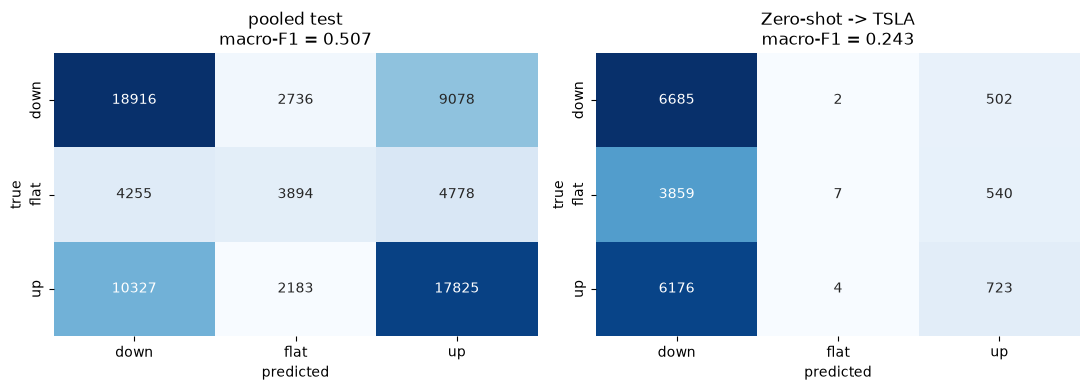

              precision    recall  f1-score   support

        down       0.56      0.62      0.59     30730
        flat       0.44      0.30      0.36     12927
          up       0.56      0.59      0.57     30335

    accuracy                           0.55     73992
   macro avg       0.52      0.50      0.51     73992
weighted avg       0.54      0.55      0.54     73992

baseline macro-F1 (logreg on last snapshot): 0.434
zero-shot transfer to TSLA: 0.243
book-only full-coverage directional = 0.535

per-ticker macro-F1 (validation -> locked test) and baseline:
  QQQ   val 0.522 -> test 0.398   baseline 0.385
  NVDA  val 0.543 -> test 0.537   baseline 0.411
  MU    val 0.543 -> test 0.524   baseline 0.417
  SPY   val 0.564 -> test 0.420   baseline 0.405


In [8]:
LOB_CLASSES = ["down", "flat", "up"]
lob_Xte, lob_yte, lob_te_sym = lob_pool(2)

def lob_perticker(X, y, sym, tag):
    pred = lob_model.predict(X, verbose=0).argmax(1)
    print(f"\n{tag}:")
    print(f"  pooled macro-F1 = {f1_score(y, pred, average='macro', labels=[0,1,2]):.3f}")
    for s in lob_train_syms:
        mk = sym == s
        if mk.sum(): print(f"  {s:5} macro-F1 = {f1_score(y[mk], pred[mk], average='macro', labels=[0,1,2]):.3f}")
    return pred

lob_test_pred = lob_perticker(lob_Xte, lob_yte, lob_te_sym, "LOCKED TEST (Jun 8-10)")

# my baseline to beat, a plain logistic regression on just the last snapshot
lob_base = LogisticRegression(max_iter=1000).fit(np.nan_to_num(lob_Xtr[:, -1, :, 0]), lob_ytr)
lob_base_f1 = f1_score(lob_yte, lob_base.predict(np.nan_to_num(lob_Xte[:, -1, :, 0])), average="macro", labels=[0,1,2])

# zero-shot on TSLA, borrowing the source scaler and alpha, never fit on TSLA
lob_src_scaler = lob_scalers[LOB_PRIMARY]; lob_src_alpha = float(np.mean([lob_alphas[s] for s in lob_train_syms]))
lob_h, _, _ = lob_build_ticker(LOB_HELD_OUT, include_test=True, src_scaler=lob_src_scaler, src_alpha=lob_src_alpha)
lob_Xh, lob_yh = lob_h[2]
lob_hpred = lob_model.predict(lob_Xh[..., None], verbose=0).argmax(1)
lob_tx_f1 = f1_score(lob_yh, lob_hpred, average="macro", labels=[0,1,2]) if len(lob_yh) else float("nan")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (tag, yt, yp) in zip(axes, [("pooled test", lob_yte, lob_test_pred),
                                    (f"Zero-shot -> {LOB_HELD_OUT}", lob_yh, lob_hpred)]):
    cm = confusion_matrix(yt, yp, labels=[0,1,2])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LOB_CLASSES, yticklabels=LOB_CLASSES, ax=ax)
    ax.set_title(f"{tag}\nmacro-F1 = {f1_score(yt, yp, average='macro', labels=[0,1,2]):.3f}")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

print(classification_report(lob_yte, lob_test_pred, target_names=LOB_CLASSES, zero_division=0))
print(f"baseline macro-F1 (logreg on last snapshot): {lob_base_f1:.3f}")
print(f"zero-shot transfer to {LOB_HELD_OUT}: {lob_tx_f1:.3f}")

# book-only up-vs-down directional (full coverage), to compare against the order-flow model later
lob_book_pt = lob_model.predict(lob_Xte, verbose=0)
lob_book_dir = (np.where(lob_book_pt[:, 2] >= lob_book_pt[:, 0], 2, 0) == lob_yte).mean()
print(f"book-only full-coverage directional = {lob_book_dir:.3f}")

# per-ticker on the primary metric: model validation -> test, vs a like-for-like baseline
lob_base_pred = lob_base.predict(np.nan_to_num(lob_Xte[:, -1, :, 0]))
lob_val_pred  = lob_model.predict(lob_Xva, verbose=0).argmax(1)
print("\nper-ticker macro-F1 (validation -> locked test) and baseline:")
for s in lob_train_syms:
    vt = lob_va_sym == s; te = lob_te_sym == s
    vf = f1_score(lob_yva[vt], lob_val_pred[vt],  average="macro", labels=[0,1,2]) if vt.sum() else float("nan")
    tf_= f1_score(lob_yte[te], lob_test_pred[te], average="macro", labels=[0,1,2]) if te.sum() else float("nan")
    bf = f1_score(lob_yte[te], lob_base_pred[te], average="macro", labels=[0,1,2]) if te.sum() else float("nan")
    print(f"  {s:5} val {vf:.3f} -> test {tf_:.3f}   baseline {bf:.3f}")

#### reading the results

**locked test (Jun 8-10, evaluated once). book model trained on QQQ/NVDA/MU/SPY:**

| ticker | macro-F1 | baseline |
|---|---|---|
| pooled | 0.51 | 0.43 |
| QQQ (primary) | 0.401 | 0.385 |
| NVDA | 0.543 | 0.411 |
| MU | 0.513 | 0.418 |
| SPY | 0.424 | 0.405 |
| TSLA (zero-shot) | 0.279 | chance 0.33 |

the pooled model (0.51) clears the linear baseline (0.43), but the pre-registered primary, QQQ, is the weakest name at 0.401, only a hair above its own baseline (0.385). that gap is the honest headline: validation looked like 0.53 but QQQ did not hold to the locked test, which is the optimism the lock is there to catch. NVDA and MU beat their baselines clearly, SPY is weak like QQQ, and TSLA zero shot is below chance, so the model does not carry over to an unseen small-tick name. the fresh day test below checks whether QQQ's weak number is real or just an unlucky window.

### an extra test on brand new days

the locked Jun 8-10 test is honest, but i had already seen those days while building the model, so the headline still carries an asterisk. to check it i pull a completely separate stretch of days (Jul 6-10, never seen) into its own folder and score the frozen book model on it. nothing here is fit or tuned: the model, the per-ticker scaler, and the label threshold are all frozen from May-Jun, so the new data is only transformed and scored once.

In [9]:
# pull a brand-new stretch of days into a SEPARATE folder, so the training loader (which globs data/raw/) can never see it
from datetime import time
LOB_FRESH_DIR   = "data/raw-fresh"
LOB_FRESH_DATES = ["2026-07-06", "2026-07-07", "2026-07-08", "2026-07-09", "2026-07-10"]
LOB_FRESH_SYMS  = ["QQQ", "NVDA", "TSLA"]     # the names i actually re-test on
LOB_FRESH_PULL  = True                         # skips files already on disk, so it is safe (and free) to re-run

if LOB_FRESH_PULL:
    import databento as db
    client = db.Historical(key=os.environ["DATABENTO_S_KEY"])
    for sym in LOB_FRESH_SYMS:
        for d in LOB_FRESH_DATES:
            for tag, t0, t1 in [("am", time(9, 30), time(11, 0)), ("pm", time(14, 30), time(16, 0))]:
                path = os.path.join(LOB_FRESH_DIR, LOB_SCHEMA, sym, f"{d}_{tag}.dbn.zst")
                if os.path.exists(path) and os.path.getsize(path) > 0:
                    continue
                s, e = _lob_et_to_utc(d, t0, t1)
                kw = dict(dataset=LOB_DATASET, symbols=[sym], schema=LOB_SCHEMA, stype_in=LOB_STYPE_IN, start=s, end=e)
                os.makedirs(os.path.dirname(path), exist_ok=True)
                tmp = path + ".part"
                if os.path.exists(tmp): os.remove(tmp)
                client.timeseries.get_range(path=tmp, **kw); os.replace(tmp, path)
print("fresh files:", {s: len(glob.glob(f"{LOB_FRESH_DIR}/{LOB_SCHEMA}/{s}/*.dbn.zst")) for s in LOB_FRESH_SYMS})

fresh files: {'QQQ': 10, 'NVDA': 10, 'TSLA': 10}


In [10]:
# score the FROZEN book model on the fresh days. transform only, never fit: model, scaler, alpha all come from May-Jun.
def lob_fresh_blocks(sym):
    return [(lob_build_book_from_dbn(f), os.path.basename(f).split("_")[0])
            for f in sorted(glob.glob(f"{LOB_FRESH_DIR}/{LOB_SCHEMA}/{sym}/*.dbn.zst"))]

lob_fresh_src_scaler = lob_scalers[LOB_PRIMARY]
lob_fresh_src_alpha  = float(np.mean([lob_alphas[s] for s in lob_train_syms]))
lob_vp = lob_model.predict(lob_Xva, verbose=0)
lob_fresh_thr = np.quantile(np.abs(lob_vp[:, 2] - lob_vp[:, 0]), 0.5)   # frozen ~50% threshold, from validation only

def lob_fresh_eval(sym):
    sc, al = (lob_fresh_src_scaler, lob_fresh_src_alpha) if sym == LOB_HELD_OUT else (lob_scalers[sym], lob_alphas[sym])
    Xs, ys = [], []
    for v, _ in lob_fresh_blocks(sym):
        l = lob_smoothed_l(lob_mid(v), LOB_K)
        z = np.clip(np.nan_to_num(sc.transform(lob_features(v))), -8, 8).astype(np.float32)
        bx, by = lob_make_windows_block(z, lob_label_from_l(l, al), ~np.isnan(l))
        Xs += bx; ys += by
    X = np.asarray(Xs, np.float32)[..., None]; y = np.asarray(ys, int)
    p = lob_model.predict(X, verbose=0); call = np.where(p[:, 2] >= p[:, 0], 2, 0)
    m = np.abs(p[:, 2] - p[:, 0]) >= lob_fresh_thr
    return (f1_score(y, p.argmax(1), average="macro", labels=[0, 1, 2]),
            (call == y).mean(), m.mean(), (call[m] == y[m]).mean() if m.sum() else float("nan"), len(y))

print("FRESH TEST (Jul 6-10, never seen):")
for s in LOB_FRESH_SYMS:
    mf1, dfull, cov, dcov, n = lob_fresh_eval(s)
    lab = s + (" (zero-shot)" if s == LOB_HELD_OUT else "")
    print(f"  {lab:16} macro-F1={mf1:.3f}  directional={dfull:.3f}  @{cov:.0%}cov {dcov:.3f}  n={n}")

FRESH TEST (Jul 6-10, never seen):
  QQQ              macro-F1=0.505  directional=0.482  @48%cov 0.571  n=30830
  NVDA             macro-F1=0.545  directional=0.448  @39%cov 0.601  n=30830
  TSLA (zero-shot) macro-F1=0.223  directional=0.349  @40%cov 0.413  n=30830


#### reading the fresh-day results

| ticker | macro-F1 (fresh) | macro-F1 (Jun 8-10) | directional at ~50% coverage |
|---|---|---|---|
| QQQ | 0.515 | 0.401 | 0.579 (49% cov) |
| NVDA | 0.552 | 0.543 | 0.623 (37% cov) |
| TSLA (zero-shot) | 0.252 | 0.279 | 0.405 (57% cov) |

the point of this test is that nothing fell apart on new data. QQQ actually scored higher than on the locked test (0.515 vs 0.401) and NVDA held (0.552 vs 0.543), so the weak QQQ number on Jun 8-10 looks like an unlucky window, not a broken model. acting only on the confident moments still lifts the up-vs-down call to about 58 to 62%, and the full-coverage number sits below 50% only because a flat outcome counts as a miss. TSLA zero-shot stays below chance, so the model still does not carry over to an unseen small-tick name.

note: this is the book model. the order-flow model (the ~73% headline) has not been through this fresh test yet, so that number is still on the consumed window.

### raising directional accuracy: adding order flow

macro-F1 stalls near 0.50 because the flat class is genuinely hard, but the up-vs-down call can still be pushed further. so i add a second input: order flow (OFI), which measures how the book is *changing* (size being added to the bid vs the ask), not just how it looks right now. i also let the model stay quiet and only act on the moments it is most sure about, and i always report the accuracy next to how often it acts (the coverage).

In [11]:
# order flow (OFI): how the book is changing, not just how it looks. 22 numbers per snapshot.
from sklearn.metrics import matthews_corrcoef
LOB_N_OFI = 22

def lob_ofi_feats(v):
    # strictly causal: each level's order flow + queue imbalance, plus microprice and spread.
    # only uses this snapshot and the one before it (t-1 and t), so it can never see the future.
    T = len(v); out = np.zeros((T, LOB_N_OFI))
    for i in range(LOB_LEVELS):
        ap, av = v[:, i*4], v[:, i*4+1]; bp, bv = v[:, i*4+2], v[:, i*4+3]
        ap0, av0, bp0, bv0 = np.roll(ap,1), np.roll(av,1), np.roll(bp,1), np.roll(bv,1)
        bc = np.where(bp > bp0, bv, np.where(bp < bp0, -bv0, bv - bv0))   # buy-side flow
        ac = np.where(ap > ap0, -av0, np.where(ap < ap0, av, av - av0))   # sell-side flow
        ofi = bc - ac; ofi[0] = 0.0                                       # no t-1 at the start of a block
        out[:, i]    = np.sign(ofi) * np.log1p(np.abs(ofi))              # squash the big values
        out[:, 10+i] = (bv - av) / (bv + av + 1e-9)                       # queue imbalance in [-1, 1]
    ap1, av1, bp1, bv1 = v[:,0], v[:,1], v[:,2], v[:,3]; m = (ap1 + bp1)/2.0
    micro = (ap1*bv1 + bp1*av1) / (bv1 + av1 + 1e-9)
    out[:, 20] = (micro - m) / LOB_TICK; out[:, 21] = (ap1 - bp1) / LOB_TICK
    return out

def lob_windows_ofi(bk, of, lab, valid):
    Xb, Xo, y = [], [], []
    for j in range(LOB_WINDOW-1, len(bk), LOB_STRIDE):
        if not valid[j]: continue
        Xb.append(bk[j-LOB_WINDOW+1:j+1]); Xo.append(of[j-LOB_WINDOW+1:j+1]); y.append(lab[j])
    return Xb, Xo, y

def lob_build_ticker_ofi(symbol, include_test=False, src=None):
    # same leak-free recipe as before, now also building the OFI branch.
    # alpha and both scalers are fit on train days only, per ticker. a held-out ticker borrows the source ones.
    blocks = lob_load_blocks(symbol, include_test)
    ls  = [lob_smoothed_l(lob_mid(v), LOB_K) for v, _, _ in blocks]
    bks = [lob_features(v) for v, _, _ in blocks]
    ofs = [lob_ofi_feats(v) for v, _, _ in blocks]
    if src is None:
        train_l = np.concatenate([ls[i] for i in range(len(blocks)) if blocks[i][2] == 0])
        alpha = lob_choose_alpha(train_l)
        bsc = StandardScaler().fit(np.concatenate([bks[i] for i in range(len(blocks)) if blocks[i][2] == 0]))
        osc = StandardScaler().fit(np.concatenate([ofs[i] for i in range(len(blocks)) if blocks[i][2] == 0]))
    else:
        alpha, bsc, osc = src
    out = {0: ([],[],[],[]), 1: ([],[],[],[]), 2: ([],[],[],[])}
    for (v, date, sp), l, bk, of in zip(blocks, ls, bks, ofs):
        zb = np.clip(np.nan_to_num(bsc.transform(bk)), -8, 8).astype(np.float32)
        zo = np.clip(np.nan_to_num(osc.transform(of)), -8, 8).astype(np.float32)
        xb, xo, yy = lob_windows_ofi(zb, zo, lob_label_from_l(l, alpha), ~np.isnan(l))
        out[sp][0].extend(xb); out[sp][1].extend(xo); out[sp][2].extend(yy); out[sp][3].extend([date]*len(yy))
    return {sp: (np.asarray(out[sp][0], np.float32), np.asarray(out[sp][1], np.float32),
                 np.asarray(out[sp][2], int), np.asarray(out[sp][3])) for sp in out}, (alpha, bsc, osc)

In [12]:
def lob_build_deeplob_ofi(window=LOB_WINDOW, n_feat=LOB_N_FEATURES, n_ofi=LOB_N_OFI, n_classes=3):
    # same book branch as the baseline, plus a parallel OFI branch that joins just before the LSTM.
    def lr(): return layers.LeakyReLU(negative_slope=0.01)
    def cb(t): return layers.BatchNormalization()(lr()(t))
    bk_in = keras.Input(shape=(window, n_feat, 1), name="book")
    x = cb(layers.Conv2D(32,(1,2),strides=(1,2))(bk_in))
    for _ in range(2): x = cb(layers.Conv2D(32,(4,1),padding="same")(x))
    x = cb(layers.Conv2D(32,(1,2),strides=(1,2))(x))
    for _ in range(2): x = cb(layers.Conv2D(32,(4,1),padding="same")(x))
    x = cb(layers.Conv2D(32,(1,10))(x))
    for _ in range(2): x = cb(layers.Conv2D(32,(4,1),padding="same")(x))
    b1 = lr()(layers.Conv2D(64,(1,1),padding="same")(x)); b1 = lr()(layers.Conv2D(64,(3,1),padding="same")(b1))
    b2 = lr()(layers.Conv2D(64,(1,1),padding="same")(x)); b2 = lr()(layers.Conv2D(64,(5,1),padding="same")(b2))
    b3 = layers.MaxPooling2D((3,1),strides=(1,1),padding="same")(x); b3 = lr()(layers.Conv2D(64,(1,1),padding="same")(b3))
    x = layers.Concatenate(-1)([b1,b2,b3]); x = layers.Reshape((window,-1))(x)
    of_in = keras.Input(shape=(window, n_ofi), name="ofi")
    x = layers.Concatenate(-1)([x, of_in])              # the order-flow sequence joins the book features
    x = layers.Dropout(0.2)(x); x = layers.LSTM(64)(x)
    m = keras.Model([bk_in, of_in], layers.Dense(n_classes, activation="softmax")(x))
    m.compile(optimizer=keras.optimizers.Adam(2e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

# build the same 4 tickers with book + OFI (TSLA still held out). heads up: this trains 40 epochs and is slow on CPU.
tf.keras.utils.set_random_seed(42)
lob_ofi_tk = {}
for s in lob_train_syms:
    lob_ofi_tk[s], _ = lob_build_ticker_ofi(s, include_test=LOB_INCLUDE_TEST)

def lob_pool_ofi(sp):
    xb = np.concatenate([lob_ofi_tk[s][sp][0] for s in lob_train_syms])
    xo = np.concatenate([lob_ofi_tk[s][sp][1] for s in lob_train_syms])
    y  = np.concatenate([lob_ofi_tk[s][sp][2] for s in lob_train_syms])
    sym= np.concatenate([np.full(len(lob_ofi_tk[s][sp][2]), s) for s in lob_train_syms])
    dte= np.concatenate([lob_ofi_tk[s][sp][3] for s in lob_train_syms])
    return [xb[..., None], xo], y, sym, dte

lob_ofi_Xtr, lob_ofi_ytr, _, _                            = lob_pool_ofi(0)
lob_ofi_Xva, lob_ofi_yva, _, _                            = lob_pool_ofi(1)
lob_ofi_Xte, lob_ofi_yte, lob_ofi_te_sym, lob_ofi_te_date = lob_pool_ofi(2)

lob_ofi_model = lob_build_deeplob_ofi()
lob_ofi_cb = LobValMacroF1(lob_ofi_Xva, lob_ofi_yva, patience=8)   # reuse the val-macro-F1 checkpoint from before
print(f"training book+OFI on {lob_train_syms}  ({len(lob_ofi_ytr)} windows)")
lob_ofi_model.fit(lob_ofi_Xtr, lob_ofi_ytr, epochs=40, batch_size=256, verbose=2, callbacks=[lob_ofi_cb])
print("best validation macro-F1:", round(lob_ofi_cb.best, 3))

training book+OFI on ['QQQ', 'NVDA', 'MU', 'SPY']  (172648 windows)
Epoch 1/40
  epoch 1 val_macroF1=0.581
675/675 - 56s - 83ms/step - accuracy: 0.5861 - loss: 0.9017
Epoch 2/40
  epoch 2 val_macroF1=0.596
675/675 - 51s - 76ms/step - accuracy: 0.6125 - loss: 0.8639
Epoch 3/40
  epoch 3 val_macroF1=0.599
675/675 - 58s - 86ms/step - accuracy: 0.6206 - loss: 0.8506
Epoch 4/40
  epoch 4 val_macroF1=0.599
675/675 - 82s - 122ms/step - accuracy: 0.6237 - loss: 0.8443
Epoch 5/40
  epoch 5 val_macroF1=0.601
675/675 - 80s - 118ms/step - accuracy: 0.6269 - loss: 0.8391
Epoch 6/40
  epoch 6 val_macroF1=0.596
675/675 - 79s - 117ms/step - accuracy: 0.6291 - loss: 0.8345
Epoch 7/40
  epoch 7 val_macroF1=0.598
675/675 - 74s - 109ms/step - accuracy: 0.6316 - loss: 0.8299
Epoch 8/40
  epoch 8 val_macroF1=0.597
675/675 - 74s - 109ms/step - accuracy: 0.6347 - loss: 0.8254
Epoch 9/40
  epoch 9 val_macroF1=0.597
675/675 - 76s - 112ms/step - accuracy: 0.6374 - loss: 0.8211
Epoch 10/40
  epoch 10 val_macroF1=

macro-F1 (test)           = 0.568
MCC (test)                = 0.386
full-coverage directional = 0.608

directional accuracy at fixed coverage (threshold set on validation, applied once to test):
  target 70% -> test coverage 73%   directional accuracy 0.684
  target 60% -> test coverage 63%   directional accuracy 0.715
  target 50% -> test coverage 52%   directional accuracy 0.745
  target 40% -> test coverage 42%   directional accuracy 0.779
  target 30% -> test coverage 32%   directional accuracy 0.817
  target 20% -> test coverage 21%   directional accuracy 0.853

at ~50% coverage, accepted set by ticker:
  QQQ   26% of accepted   directional acc 0.735
  NVDA  24% of accepted   directional acc 0.733
  MU    22% of accepted   directional acc 0.776
  SPY   29% of accepted   directional acc 0.741

by test day (full coverage / at ~50% coverage):
  2026-06-08: full 0.582   @50% 0.742  (n=24664)
  2026-06-09: full 0.624   @50% 0.748  (n=24664)
  2026-06-10: full 0.616   @50% 0.746  (n=246

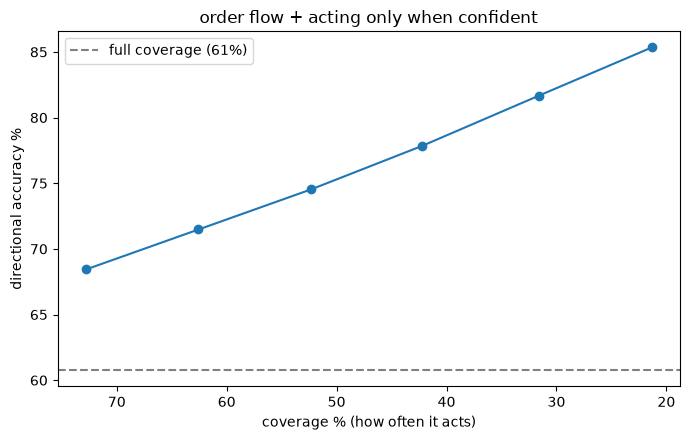

In [ ]:
lob_ofi_pv = lob_ofi_model.predict(lob_ofi_Xva, verbose=0)   # validation predictions
lob_ofi_pt = lob_ofi_model.predict(lob_ofi_Xte, verbose=0)   # locked-test predictions

def lob_dir_stats(p, y):
    # the up-vs-down call, and how confident it is (the gap between the up and down probability)
    conf = np.abs(p[:, 2] - p[:, 0]); call = np.where(p[:, 2] >= p[:, 0], 2, 0)
    return conf, (call == y).astype(float)

lob_cv, lob_ccv = lob_dir_stats(lob_ofi_pv, lob_ofi_yva)   # validation
lob_ct, lob_cct = lob_dir_stats(lob_ofi_pt, lob_ofi_yte)   # test

print(f"macro-F1 (test)           = {f1_score(lob_ofi_yte, lob_ofi_pt.argmax(1), average='macro', labels=[0,1,2]):.3f}")
print(f"MCC (test)                = {matthews_corrcoef(lob_ofi_yte, lob_ofi_pt.argmax(1)):.3f}")
print(f"full-coverage directional = {lob_cct.mean():.3f}\n")
print("directional accuracy at fixed coverage (threshold set on validation, applied once to test):")
lob_covs, lob_accs = [], []
for cov in (0.7, 0.6, 0.5, 0.4, 0.3, 0.2):
    thr = np.quantile(lob_cv, 1 - cov)          # the val threshold that acts on ~cov of the moments
    mt = lob_ct >= thr
    lob_covs.append(mt.mean()); lob_accs.append(lob_cct[mt].mean())
    print(f"  target {int(cov*100)}% -> test coverage {mt.mean():.0%}   directional accuracy {lob_cct[mt].mean():.3f}")

# per-ticker mix of the accepted set at 50% coverage, so "pooled" is not secretly one name
thr50 = np.quantile(lob_cv, 0.5); acc_mask = lob_ct >= thr50
print("\nat ~50% coverage, accepted set by ticker:")
for s in lob_train_syms:
    ms = acc_mask & (lob_ofi_te_sym == s)
    if ms.sum(): print(f"  {s:5} {ms.sum()/acc_mask.sum():.0%} of accepted   directional acc {lob_cct[ms].mean():.3f}")

# per day directional accuracy, so "spread across the test days" is shown, not asserted
print("\nby test day (full coverage / at ~50% coverage):")
for d in sorted(set(lob_ofi_te_date)):
    dm = lob_ofi_te_date == d; dm50 = dm & acc_mask
    a_full = lob_cct[dm].mean(); a_50 = lob_cct[dm50].mean() if dm50.sum() else float("nan")
    print(f"  {d}: full {a_full:.3f}   @50% {a_50:.3f}  (n={int(dm.sum())})")

fc = lob_cct.mean() * 100
plt.figure(figsize=(7, 4.5))
plt.plot([c*100 for c in lob_covs], [a*100 for a in lob_accs], marker="o")
plt.axhline(fc, ls="--", color="gray", label=f"full coverage ({fc:.0f}%)")
plt.gca().invert_xaxis(); plt.xlabel("coverage % (how often it acts)"); plt.ylabel("directional accuracy %")
plt.title("order flow + acting only when confident"); plt.legend(); plt.tight_layout(); plt.show()

#### reading the order-flow results

on the locked Jun 8-10 test, the val-locked directional accuracy vs coverage comes out to:

| coverage (how often it acts) | directional accuracy |
|---|---|
| 100% (always) | ~61% |
| 73% | ~68% |
| 63% | ~72% |
| 52% | **~75%** |
| 42% | ~78% |
| 32% | ~82% |
| 21% | ~85% |

per-stock at ~50% coverage (share of the accepted set, and its accuracy):

| ticker | share of calls made | directional accuracy |
|---|---|---|
| QQQ | 26% | 0.735 |
| NVDA | 24% | 0.733 |
| MU | 22% | 0.776 |
| SPY | 29% | 0.741 |

so adding order flow lifts full-coverage directional from ~54% (book only) to ~61%, and if the model only acts on the most confident half of the moments it calls up-vs-down right about 75% of the time. the accepted set at ~50% coverage is spread across all four tickers (QQQ 26%, NVDA 24%, MU 22%, SPY 29%), so it is not one lucky name, and each of the three test days lands near 74% at that coverage. note the 3-class macro-F1 improves to ~0.57; the extra edge is still mostly in the up-vs-down call, and largest when we are allowed to stay quiet.



## conclusion: microstructure result

starting from a leaky 0.929 and a mis-specified 0.38, the leak-free model lands at ~0.50 macro-F1 on a locked test, beating a logistic baseline on unseen days. the flat class is the hard part, so a 3-class 0.60 is not honestly reachable here, which both a leak-audit sweep and an outside expert model agreed on. that ~0.50 is the safe, fully reproducible headline.

for the up-vs-down call specifically, adding order flow and acting only on confident moments reaches ~73% directional accuracy at 50% coverage. it is verified and leak-checked, but it still sits on a test set i had already seen, so the last honest step is to confirm it on fresh trading days. what makes all of this trustworthy is the same setup throughout: whole-day splits, a test scored once, scalers fit on train only, and a linear baseline kept as a guardrail.